In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from tensorflow import keras
from tensorflow.keras import layers


In [2]:
df = pd.read_csv("D:/pdf/customer_churn.csv")


In [3]:
df.head()


,Names,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Onboard_date,Location,Company,Churn
0,Cameron Williams,42.0,11066.80,0,7.22,8.0,2013-08-30 07:00:40,"10265 Elizabeth Mission Barkerburgh, AK 89518",Harvey LLC,1
1,Kevin Mueller,41.0,11916.22,0,6.50,11.0,2013-08-13 00:38:46,"6157 Frank Gardens Suite 019 Carloshaven, RI 1...",Wilson PLC,1
2,Eric Lozano,38.0,12884.75,0,6.67,12.0,2016-06-29 06:20:07,"1331 Keith Court Alyssahaven, DE 90114","Miller, Johnson and Wallace",1
3,Phillip White,42.0,8010.76,0,6.71,10.0,2014-04-22 12:43:12,"13120 Daniel Mount Angelabury, WY 30645-4695",Smith Inc,1
4,Cynthia Norton,37.0,9191.58,0,5.56,9.0,2016-01-19 15:31:15,"765 Tricia Row Karenshire, MH 71730",Love-Jones,1


In [4]:
df.shape


(900, 10)

In [5]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Names            900 non-null    object 
 1   Age              900 non-null    float64
 2   Total_Purchase   900 non-null    float64
 3   Account_Manager  900 non-null    int64  
 4   Years            900 non-null    float64
 5   Num_Sites        900 non-null    float64
 6   Onboard_date     900 non-null    object 
 7   Location         900 non-null    object 
 8   Company          900 non-null    object 
 9   Churn            900 non-null    int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 70.4+ KB


In [6]:
df.describe()


,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,41.816667,10062.824033,0.481111,5.273156,8.587778,0.166667
std,6.127560,2408.644532,0.499921,1.274449,1.764836,0.372885
min,22.000000,100.000000,0.000000,1.000000,3.000000,0.000000
25%,38.000000,8497.122500,0.000000,4.450000,7.000000,0.000000
50%,42.000000,10045.870000,0.000000,5.215000,8.000000,0.000000
75%,46.000000,11760.105000,1.000000,6.110000,10.000000,0.000000
max,65.000000,18026.010000,1.000000,9.150000,14.000000,1.000000


In [7]:
df.isnull().sum()


Names              0
Age                0
Total_Purchase     0
Account_Manager    0
Years              0
Num_Sites          0
Onboard_date       0
Location           0
Company            0
Churn              0
dtype: int64

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df.drop_duplicates(inplace=True)


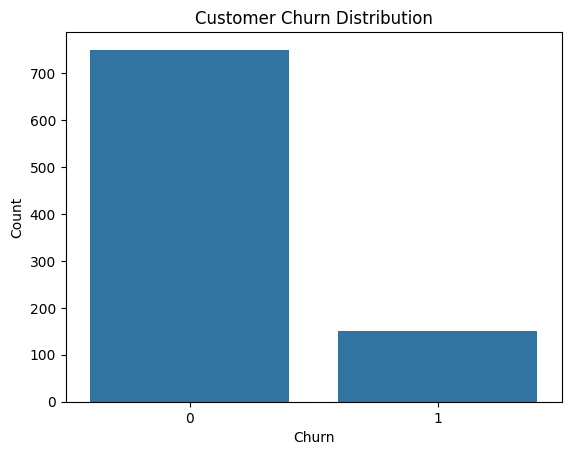

In [10]:
sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()


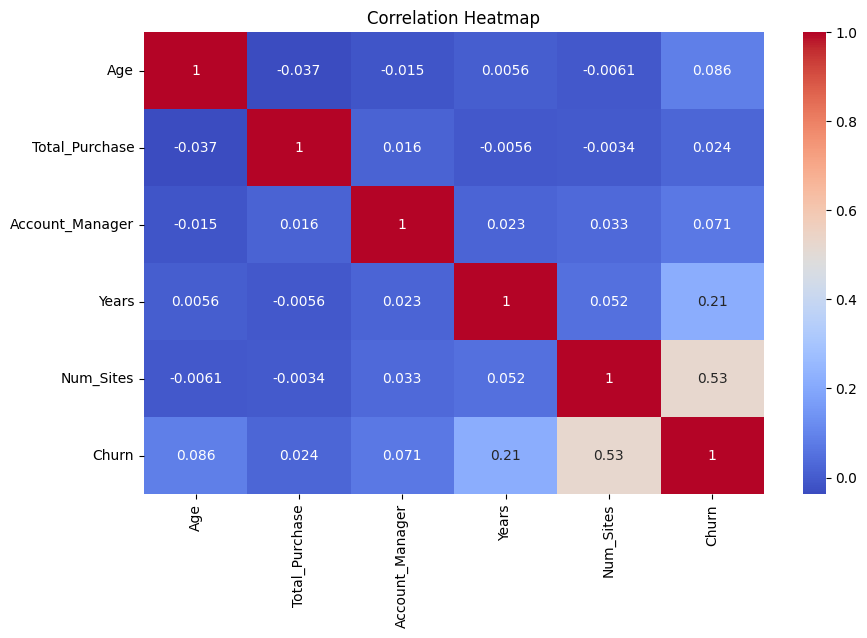

In [11]:
plt.figure(figsize=(10, 6))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()


In [12]:
df.dtypes


Names               object
Age                float64
Total_Purchase     float64
Account_Manager      int64
Years              float64
Num_Sites          float64
Onboard_date        object
Location            object
Company             object
Churn                int64
dtype: object

In [13]:
df = pd.get_dummies(df, drop_first=True)


In [14]:
df.head()


,Age,Total_Purchase,Account_Manager,Years,Num_Sites,Churn,Names_Aaron Meyer,Names_Aaron West,Names_Abigail Gonzalez,Names_Abigail Jennings,...,"Company_Yates, Martinez and Cox",Company_Young and Sons,"Company_Young, Porter and Hill",Company_Young-Dunn,Company_Young-Newman,Company_Yu-Murillo,Company_Zamora-Cherry,Company_Zhang-Brown,Company_Zimmerman Group,"Company_Zuniga, Clark and Shaffer"
0,42.0,11066.80,0,7.22,8.0,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,41.0,11916.22,0,6.50,11.0,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,38.0,12884.75,0,6.67,12.0,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,42.0,8010.76,0,6.71,10.0,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,37.0,9191.58,0,5.56,9.0,1,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [15]:
X = df.drop('Churn', axis=1)
y = df['Churn']


In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [17]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [18]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


X_train: (720, 3573)
X_test : (180, 3573)
y_train: (720,)
y_test : (180,)


In [19]:
# ============================================================
# CELL 12 - SAVE PREPROCESSOR
# ============================================================
import pickle
with open("preprocessor.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("preprocessor.pkl saved successfully")

preprocessor.pkl saved successfully


In [20]:
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),
    
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    
    layers.Dense(1, activation='sigmoid')
])


In [21]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        57,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 57,329 (223.94 KB)

 Trainable params: 57,329 (223.94 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [23]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6406 - loss: 0.6424 - val_accuracy: 0.8333 - val_loss: 0.5807
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8505 - loss: 0.3861 - val_accuracy: 0.8333 - val_loss: 0.6102
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8951 - loss: 0.2628 - val_accuracy: 0.8333 - val_loss: 0.5905
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9410 - loss: 0.1783 - val_accuracy: 0.8333 - val_loss: 0.6888
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9582 - loss: 0.1320 - val_accuracy: 0.8333 - val_loss: 0.7632
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9785 - loss: 0.0923 - val_accuracy: 0.8333 - val_loss: 0.8665
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9785 - loss: 0.0670 - val_accuracy: 0.8333 - val_loss: 0.9746
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9831 - loss: 0.0567 - val_accuracy: 0.8333 - val_loss

In [24]:
history.history.keys()


dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

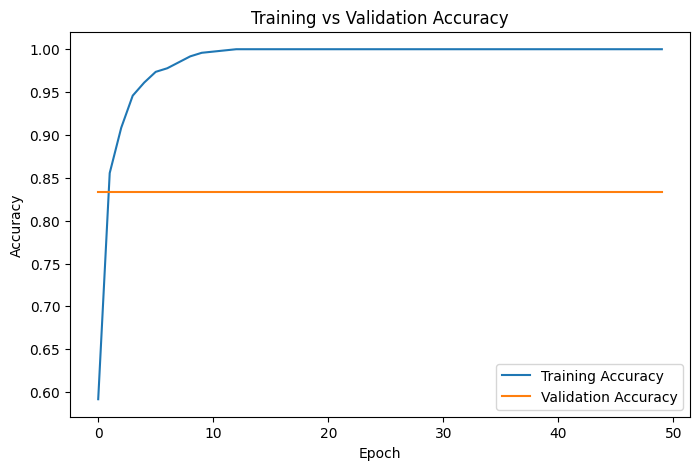

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()

plt.show()


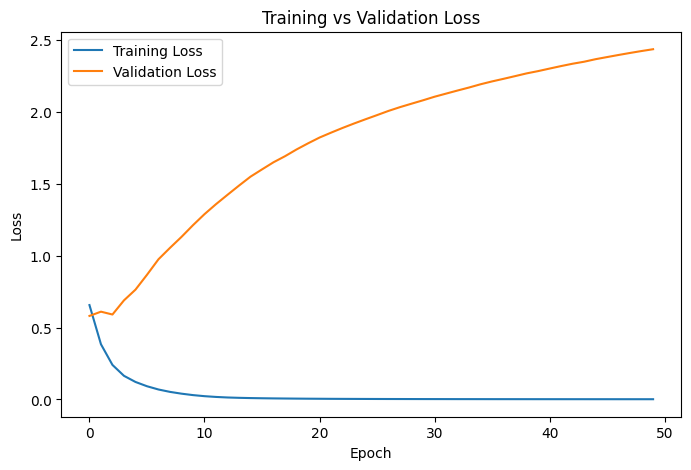

In [26]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()

plt.show()


In [27]:
loss, accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)


Test Loss: 2.435263156890869
Test Accuracy: 0.8333333134651184


In [28]:
y_pred_probability = model.predict(X_test)


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


In [29]:
y_pred = (y_pred_probability >= 0.5).astype(int)


In [30]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.8333333333333334


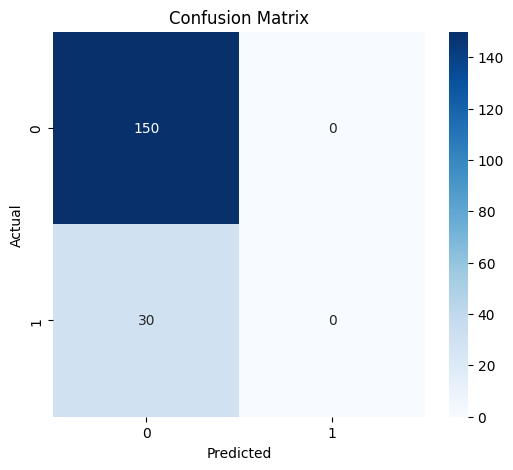

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()


In [32]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.83      1.00      0.91       150
           1       0.00      0.00      0.00        30

    accuracy                           0.83       180
   macro avg       0.42      0.50      0.45       180
weighted avg       0.69      0.83      0.76       180



c:\Users\kumar\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\kumar\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\kumar\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [33]:
import pickle

with open("ann_model.pkl", "wb") as file:
    pickle.dump(model, file)


In [34]:
import os

print(os.path.abspath("ann_model.pkl"))


d:\jupyter notebooks\Deep_learning\project\Customer_Churn\ann_model.pkl


In [36]:
import pickle

with open("preprocessor.pkl", "wb") as file:
    pickle.dump(scaler, file)

print("preprocessor.pkl saved successfully")

preprocessor.pkl saved successfully
